In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import sklearn.metrics as skm
from sklearn.linear_model import LinearRegression
from scipy.stats import ks_2samp

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Functions

In [2]:
# show added factors
def show_best_added_factor(df, str_title='Score by Added Factor'):
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # make tmp df
        df_tmp = df.copy()
        # add factor
        df_tmp['tmp'] = df_tmp['ecnl_original'] + flt_factor
        # get score
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=df_tmp['ecnl_early'], 
            y_pred=df_tmp['tmp'],
        ))
        # dict row
        dict_row = {
            'Factor': flt_factor,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(df_tmp['Factor'], df_tmp['Score'])
    # get min
    flt_min = df_tmp['Score'].min()
    flt_factor = df_tmp[df_tmp['Score'] == flt_min].copy()['Factor'].iloc[0]
    str_title = f"""
    {str_title}
    Best Factor = {flt_factor:0.4f}; Score = {flt_min:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Factor')
    ax.set_ylabel('Score')
    # show
    plt.show()
    # return
    return flt_min, flt_factor

In [3]:
# show multiplicative factors
def show_best_multiplicative_factor(df, str_title='Score by Multiplicative Factor'):
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # make tmp df
        df_tmp = df.copy()
        # add factor
        df_tmp['tmp'] = df_tmp['ecnl_original'] * flt_factor
        # get score
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=df_tmp['ecnl_early'], 
            y_pred=df_tmp['tmp'],
        ))
        # dict row
        dict_row = {
            'Factor': flt_factor,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(df_tmp['Factor'], df_tmp['Score'])
    # get min
    flt_min = df_tmp['Score'].min()
    flt_factor = df_tmp[df_tmp['Score'] == flt_min].copy()['Factor'].iloc[0]
    str_title = f"""
    {str_title}
    Best Factor = {flt_factor:0.4f}; Score = {flt_min:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Factor')
    ax.set_ylabel('Score')
    # show
    plt.show()
    # return
    return flt_min, flt_factor

In [4]:
def transformation_tuner(df):
    # list trans
    list_str_trans = [
        'None',
        'Log',
        'Log10',
        'Square',
        'Square_Root',
        'Cube',
        'Cube_Root',
        'Reciprocal',
    ]
    # empty list
    list_dict_row = []
    for str_trans in tqdm(list_str_trans):
        # copy df
        df_tmp = df.copy()
        # logic
        if str_trans == 'None':
            # apply transformation
            df_tmp['ecnl_original'] = df_tmp['ecnl_original']
        elif str_trans == 'Log':
            # apply transformation
            df_tmp['ecnl_original'] = np.log(df_tmp['ecnl_original'])
        elif str_trans == 'Log10':
            # apply transformation
            df_tmp['ecnl_original'] = np.log10(df_tmp['ecnl_original'])
        elif str_trans == 'Square':
            # apply transformation
            df_tmp['ecnl_original'] = df_tmp['ecnl_original'] ** 2
        elif str_trans == 'Square_Root':
            # apply transformation
            df_tmp['ecnl_original'] = np.sqrt(df_tmp['ecnl_original'])
        elif str_trans == 'Cube':
            # apply transformation
            df_tmp['ecnl_original'] = df_tmp['ecnl_original'] ** 3
        elif str_trans == 'Cube_Root':
            # apply transformation
            df_tmp['ecnl_original'] = np.cbrt(df_tmp['ecnl_original'])
        elif str_trans == 'Reciprocal':
            # apply transformation
            df_tmp['ecnl_original'] = 1 / df_tmp['ecnl_original']
        else:
            break
        # create X and y
        list_cols = [
            'ecnl_original',
        ]
        X = df_tmp[list_cols]
        y = df_tmp['ecnl_early']
        # fit model
        cls_model = LinearRegression()
        try:
            cls_model.fit(X, y)
        except ValueError:
            continue
        # get intercept
        flt_intercept = cls_model.intercept_
        flt_coeff = list(cls_model.coef_)[0]
        # get predictions
        df_tmp['yhat'] = cls_model.predict(X)
        # get rmse
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=df_tmp['ecnl_early'],
            y_pred=df_tmp['yhat'],
        ))
        # make row
        dict_row = {
            'Transformation': str_trans,
            'Intercept': flt_intercept,
            'Coefficient': flt_coeff,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # sort
    df_tmp.sort_values(by='Score', ascending=True, inplace=True)
    # return
    return df_tmp

### Constants

In [5]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
int_n_vals = 1000
str_target = 'ecnl_early'

Project: 20231010-gen-xii
Task: 09_early_indicators


### Output dir

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant dir

In [7]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get data

In [8]:
str_filename = 'df_ecnl_early.csv'
str_uri = f's3://{str_project}/09_early_indicators/{str_variant}/06_get_ecnl/{str_filename}'
df = pd.read_csv(str_uri)
df

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:272: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,bigaccountid__app,yhat_lgd_original,yhat_pd_original,yhat_DQ15_2,data_set,intopenbktype__app,ecnl_original,ecnl_early
0,1337511.0,0.419317,0.513062,0.597778,train,NaN,0.215136,0.250658
1,1337528.0,0.346931,0.310533,0.289732,train,7.0,0.107734,0.100517
2,1337539.0,0.471772,0.706639,0.781705,train,NaN,0.333372,0.368786
3,1337542.0,0.360220,0.448451,0.458064,train,NaN,0.161541,0.165004
4,1337547.0,0.434562,0.241002,0.271363,train,7.0,0.104730,0.117924
...,...,...,...,...,...,...,...,...
99122,3396623.0,0.335347,0.165674,0.132934,test,7.0,0.055558,0.044579
99123,3397156.0,0.303469,0.067003,0.076430,test,7.0,0.020333,0.023194
99124,3397435.0,0.285521,0.112210,0.091391,test,7.0,0.032038,0.026094
99125,3397518.0,0.481834,0.441041,0.417113,test,7.0,0.212509,0.200979


### Show distributions

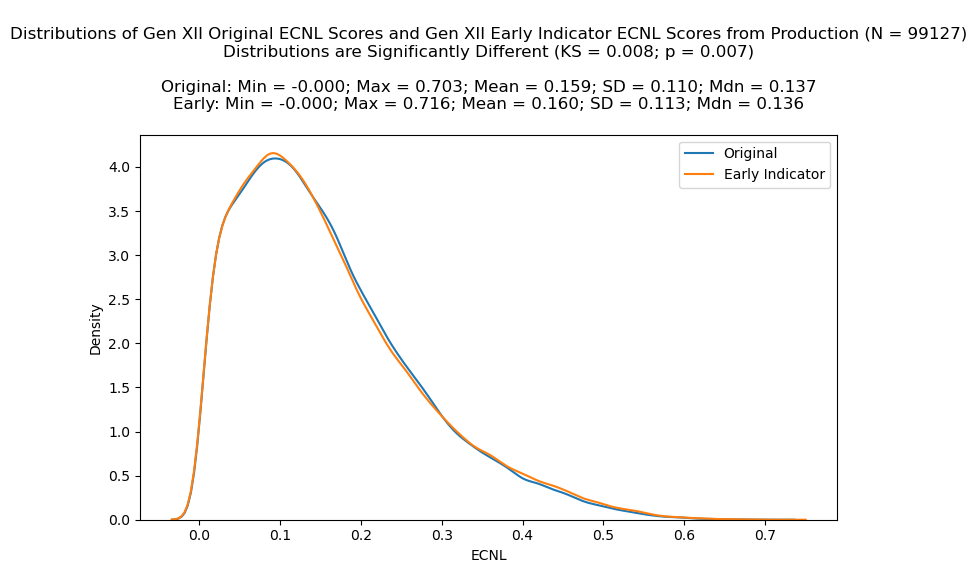

In [9]:
# ecnl_original
list_x = list(df['ecnl_original'])
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ecnl_early'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XII Original ECNL Scores and Gen XII Early Indicator ECNL Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Original: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Early: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Original')
sns.kdeplot(list_y, label='Early Indicator')
# legend
plt.legend()

# show
plt.show()

### Show original score

In [10]:
# get original score in test
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df['ecnl_early'], 
    y_pred=df['ecnl_original'],
))
print(f'Original score: {flt_score:0.4f}')

Original score: 0.0260


### Add factor

100%|██████████| 1001/1001 [00:02<00:00, 352.16it/s]


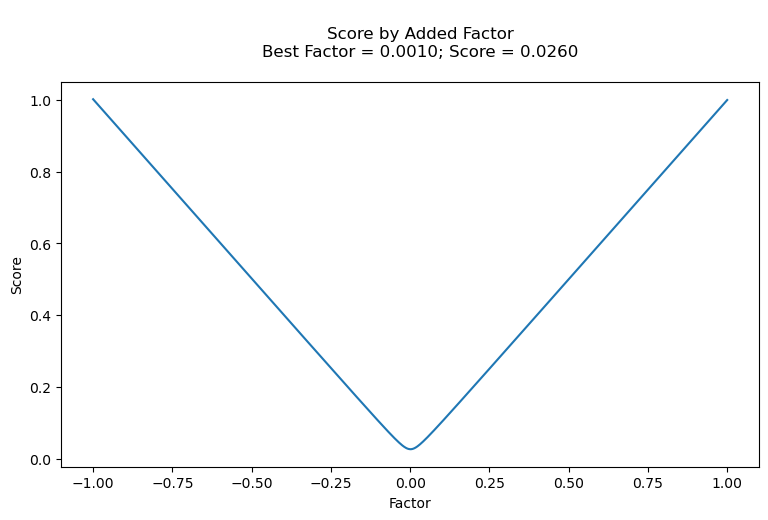

In [11]:
# show added factors
flt_min = -1
flt_max = 1
list_flt_factor = list(np.linspace(flt_min, flt_max, int_n_vals))
# ensure zero is in
list_flt_factor = list_flt_factor + [0]
list_flt_factor = list(dict.fromkeys(list_flt_factor))
list_flt_factor.sort()
flt_min, flt_factor = show_best_added_factor(
    df=df, 
    str_title='Score by Added Factor',
)

In [12]:
# get add score in test
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df['ecnl_early'], 
    y_pred=df['ecnl_original']+flt_factor,
))
print(f'Additive score: {flt_score:0.4f}')

Additive score: 0.0260


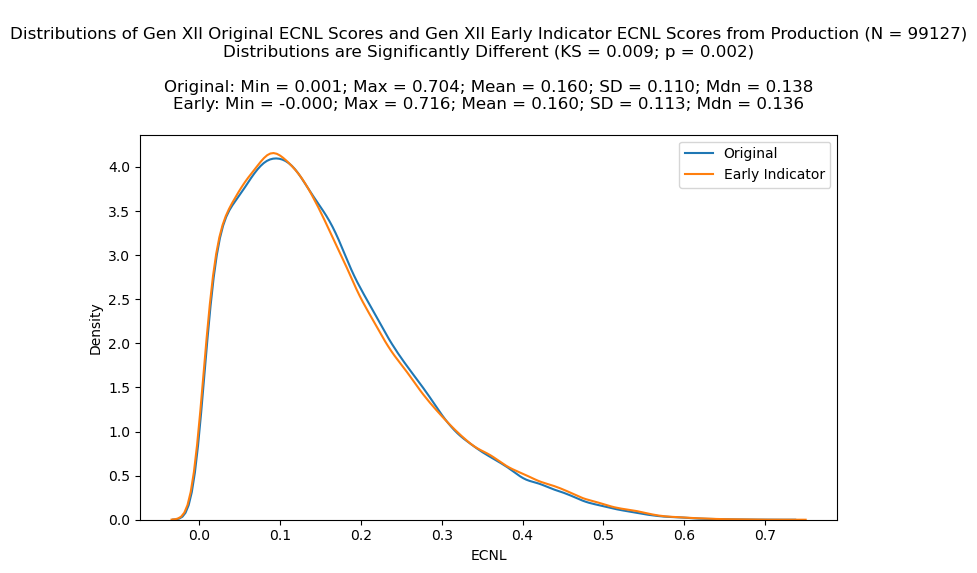

In [13]:
# ecnl_original
list_x = list(df['ecnl_original']+flt_factor)
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ecnl_early'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XII Original ECNL Scores and Gen XII Early Indicator ECNL Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Original: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Early: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Original')
sns.kdeplot(list_y, label='Early Indicator')
# legend
plt.legend()

# show
plt.show()

### Multiplicative

100%|██████████| 1001/1001 [00:02<00:00, 372.28it/s]


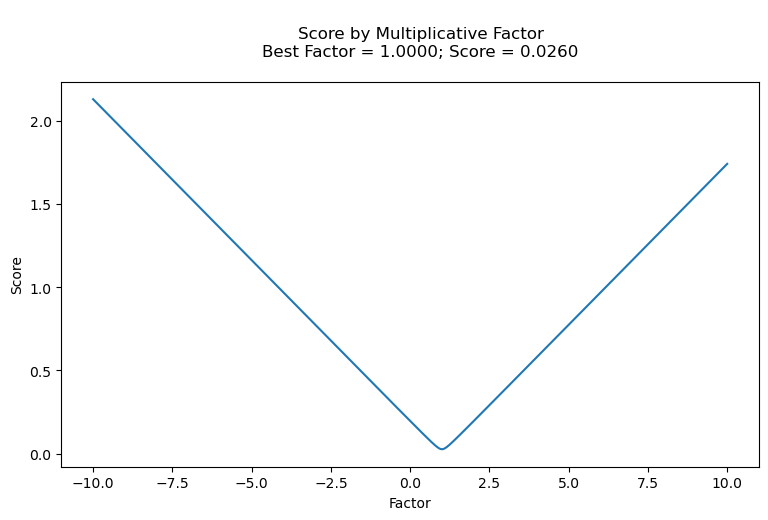

In [14]:
flt_min = -10.0
flt_max = 10.0
list_flt_factor = list(np.linspace(flt_min, flt_max, int_n_vals))
# ensure 1 is in
list_flt_factor = list_flt_factor + [1]
list_flt_factor = list(dict.fromkeys(list_flt_factor))
list_flt_factor.sort()
flt_min, flt_factor = show_best_multiplicative_factor(
    df=df, 
    str_title='Score by Multiplicative Factor',
)

In [15]:
# get add score in test
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df['ecnl_early'], 
    y_pred=df['ecnl_original']*flt_factor,
))
print(f'Additive score: {flt_score:0.4f}')

Additive score: 0.0260


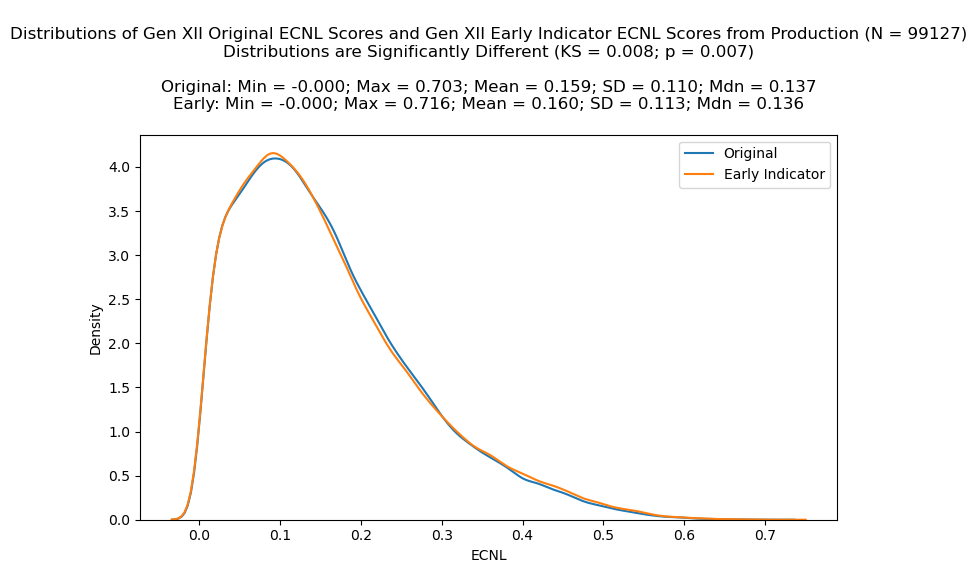

In [16]:
# ecnl_original
list_x = list(df['ecnl_original']*flt_factor)
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ecnl_early'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XII Original ECNL Scores and Gen XII Early Indicator ECNL Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Original: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Early: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Original')
sns.kdeplot(list_y, label='Early Indicator')
# legend
plt.legend()

# show
plt.show()

### Linear model

In [17]:
df_tuned = transformation_tuner(df=df)
df_tuned

  0%|          | 0/8 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 8/8 [00:00<00:00, 133.46it/s]


,Transformation,Intercept,Coefficient,Score
0,None,0.001612,0.996803,0.026004
3,Cube_Root,-0.238944,0.783156,0.042650
1,Square,0.082145,2.086349,0.044372
2,Cube,0.114917,4.079504,0.064585
4,Reciprocal,0.170636,-0.000670,0.108473


In [18]:
# get trans
str_trans = df_tuned['Transformation'].iloc[0]
flt_int = df_tuned['Intercept'].iloc[0]
flt_coef = df_tuned['Coefficient'].iloc[0]

In [19]:
# transform
df['yhat'] = df['ecnl_original']
# formula
df['yhat'] = flt_int + (df['yhat'] * flt_coef)
df

,bigaccountid__app,yhat_lgd_original,yhat_pd_original,yhat_DQ15_2,data_set,intopenbktype__app,ecnl_original,ecnl_early,yhat
0,1337511.0,0.419317,0.513062,0.597778,train,NaN,0.215136,0.250658,0.216060
1,1337528.0,0.346931,0.310533,0.289732,train,7.0,0.107734,0.100517,0.109001
2,1337539.0,0.471772,0.706639,0.781705,train,NaN,0.333372,0.368786,0.333918
3,1337542.0,0.360220,0.448451,0.458064,train,NaN,0.161541,0.165004,0.162636
4,1337547.0,0.434562,0.241002,0.271363,train,7.0,0.104730,0.117924,0.106007
...,...,...,...,...,...,...,...,...,...
99122,3396623.0,0.335347,0.165674,0.132934,test,7.0,0.055558,0.044579,0.056992
99123,3397156.0,0.303469,0.067003,0.076430,test,7.0,0.020333,0.023194,0.021880
99124,3397435.0,0.285521,0.112210,0.091391,test,7.0,0.032038,0.026094,0.033547
99125,3397518.0,0.481834,0.441041,0.417113,test,7.0,0.212509,0.200979,0.213441


In [20]:
# model score
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df['ecnl_early'], 
    y_pred=df['yhat'],
))
print(f'Model score: {flt_score:0.4f}')

Model score: 0.0260


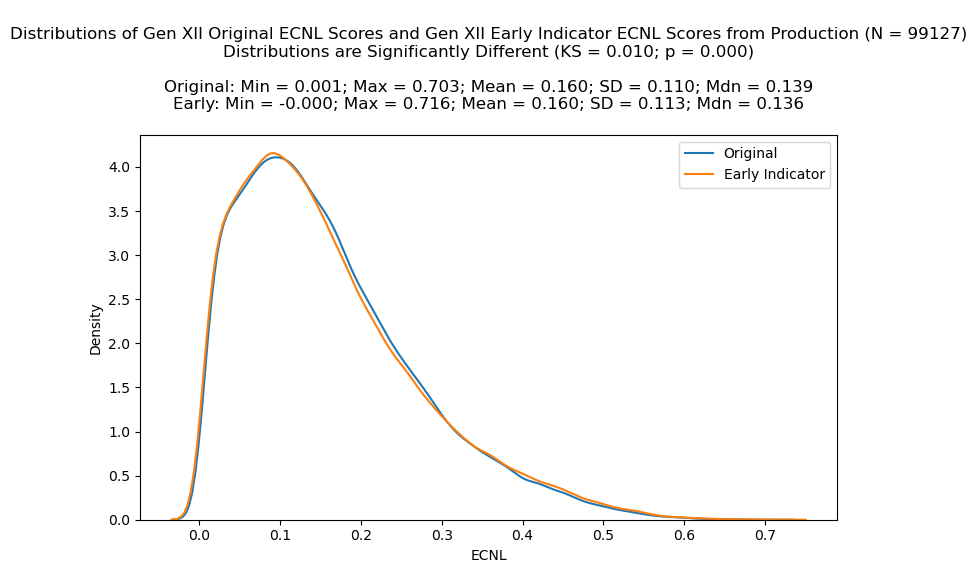

In [21]:
# ecnl_original
list_x = list(df['yhat'])
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df['ecnl_early'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XII Original ECNL Scores and Gen XII Early Indicator ECNL Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Original: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Early: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Original')
sns.kdeplot(list_y, label='Early Indicator')
# legend
plt.legend()

# show
plt.show()

### Linear interpolation with train, valid, test split

In [24]:
# train valid test split
df_train = df[df['data_set'] == 'train'].copy()
df_test = df[df['data_set'] == 'test'].copy()
df_test

,bigaccountid__app,yhat_lgd_original,yhat_pd_original,yhat_DQ15_2,data_set,intopenbktype__app,ecnl_original,ecnl_early,yhat
79354,2867541.0,0.502895,0.891058,0.959093,test,NaN,0.448109,0.482324,0.448288
79355,2867543.0,0.368214,0.359111,0.380510,test,NaN,0.132230,0.140109,0.133419
79356,2867556.0,0.551844,0.657558,0.728558,test,NaN,0.362870,0.402051,0.363321
79357,2867569.0,0.435343,0.613629,0.606470,test,NaN,0.267139,0.264023,0.267897
79358,2867589.0,0.494321,0.725824,0.730585,test,NaN,0.358790,0.361143,0.359254
...,...,...,...,...,...,...,...,...,...
99122,3396623.0,0.335347,0.165674,0.132934,test,7.0,0.055558,0.044579,0.056992
99123,3397156.0,0.303469,0.067003,0.076430,test,7.0,0.020333,0.023194,0.021880
99124,3397435.0,0.285521,0.112210,0.091391,test,7.0,0.032038,0.026094,0.033547
99125,3397518.0,0.481834,0.441041,0.417113,test,7.0,0.212509,0.200979,0.213441


In [25]:
# original score
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df_test['ecnl_early'], 
    y_pred=df_test['ecnl_original'],
))
print(f'Test score: {flt_score:0.4f}')

Test score: 0.0280


In [27]:
# original
list_x = list(df_train['ecnl_original'])
# target
list_y = list(df_train['ecnl_early'])

# target quantiles
arr_target_quantiles = np.percentile(list_y, np.linspace(0, 100, 100))
# original quantiles
arr_iv_quantiles = np.percentile(list_x, np.linspace(0, 100, 100))

# map quantiles to test data
list_z = list(df_test['ecnl_original'])
list_mapped_data = list(np.interp(list_z, arr_iv_quantiles, arr_target_quantiles))
# assign
df_test['yhat'] = list_mapped_data
df_test

,bigaccountid__app,yhat_lgd_original,yhat_pd_original,yhat_DQ15_2,data_set,intopenbktype__app,ecnl_original,ecnl_early,yhat
79354,2867541.0,0.502895,0.891058,0.959093,test,NaN,0.448109,0.482324,0.455820
79355,2867543.0,0.368214,0.359111,0.380510,test,NaN,0.132230,0.140109,0.131966
79356,2867556.0,0.551844,0.657558,0.728558,test,NaN,0.362870,0.402051,0.371022
79357,2867569.0,0.435343,0.613629,0.606470,test,NaN,0.267139,0.264023,0.270780
79358,2867589.0,0.494321,0.725824,0.730585,test,NaN,0.358790,0.361143,0.366780
...,...,...,...,...,...,...,...,...,...
99122,3396623.0,0.335347,0.165674,0.132934,test,7.0,0.055558,0.044579,0.055730
99123,3397156.0,0.303469,0.067003,0.076430,test,7.0,0.020333,0.023194,0.020244
99124,3397435.0,0.285521,0.112210,0.091391,test,7.0,0.032038,0.026094,0.032232
99125,3397518.0,0.481834,0.441041,0.417113,test,7.0,0.212509,0.200979,0.213313


In [29]:
# interpolated score
flt_score = np.sqrt(skm.mean_squared_error(
    y_true=df_test['ecnl_early'], 
    y_pred=df_test['yhat'],
))
print(f'Test score: {flt_score:0.4f}')

Test score: 0.0284


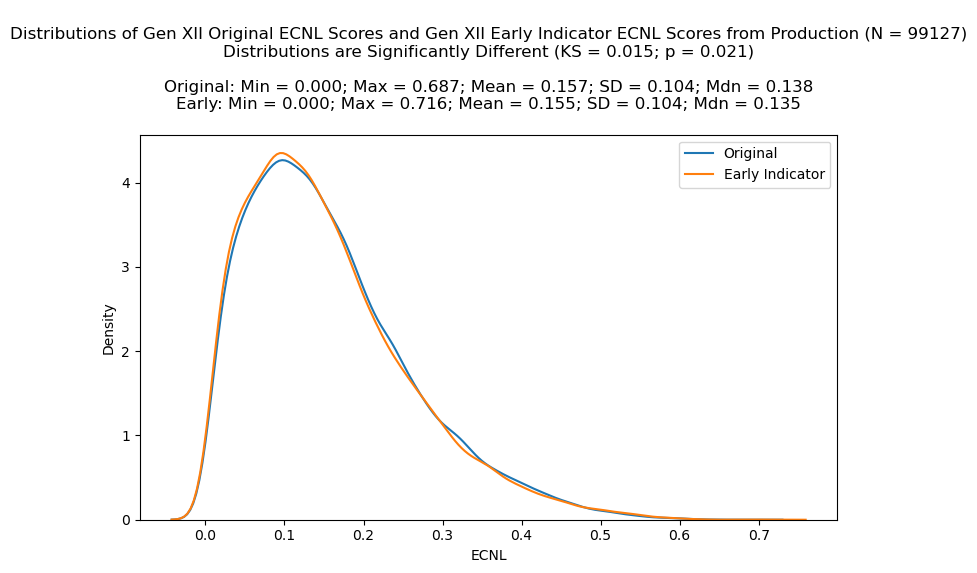

In [31]:
# ecnl_original
list_x = list(df_test['yhat'])
flt_min_x = np.min(list_x)
flt_max_x = np.max(list_x)
flt_mean_x = np.mean(list_x)
flt_std_x = np.std(list_x)
flt_mdn_x = np.median(list_x)
# gen xii
list_y = list(df_test['ecnl_early'])
flt_min_y = np.min(list_y)
flt_max_y = np.max(list_y)
flt_mean_y = np.mean(list_y)
flt_std_y = np.std(list_y)
flt_mdn_y = np.median(list_y)
# ks test
flt_ks, flt_p = ks_2samp(list_x, list_y)
# logic
if flt_p <= 0.05:
    str_sig = 'Distributions are Significantly Different'
else:
    str_sig = 'Distributions are Not Significantly Different'

# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distributions of Gen XII Original ECNL Scores and Gen XII Early Indicator ECNL Scores from Production (N = {df.shape[0]})
{str_sig} (KS = {flt_ks:0.3f}; p = {flt_p:0.3f})

Original: Min = {flt_min_x:0.3f}; Max = {flt_max_x:0.3f}; Mean = {flt_mean_x:0.3f}; SD = {flt_std_x:0.3f}; Mdn = {flt_mdn_x:0.3f}
Early: Min = {flt_min_y:0.3f}; Max = {flt_max_y:0.3f}; Mean = {flt_mean_y:0.3f}; SD = {flt_std_y:0.3f}; Mdn = {flt_mdn_y:0.3f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot lines
sns.kdeplot(list_x, label='Original')
sns.kdeplot(list_y, label='Early Indicator')
# legend
plt.legend()

# show
plt.show()